This notebook runs segmentation using the tensorstore package, and the associated changed made to the neurotorch array and predictor classes.

In [1]:
import tracemalloc
from datetime import datetime
import torch
from matplotlib import pyplot as plt
import os
import ac_segmentation
import ac_segmentation.neurotorch.datasets.dataset
from ac_segmentation.neurotorch.datasets.dataset import open_ZarrTensor, create_EmptyTensor
import ac_segmentation.neurotorch.core.predictor
import ac_segmentation.neurotorch.nets.RSUNet

Predictor = ac_segmentation.neurotorch.core.predictor.Predictor
Vector = ac_segmentation.neurotorch.datasets.datatypes.Vector
BoundingBox = ac_segmentation.neurotorch.datasets.datatypes.BoundingBox
TSArray = ac_segmentation.neurotorch.datasets.dataset.TSArray

/home/connor.laughland/miniconda3/envs/Py3.8/lib/python3.8/site-packages/ac_segmentation/neurotorch/nets/layers.py:40: UserWarning: nn.init.kaiming_normal is now deprecated in favor of nn.init.kaiming_normal_.
  init.kaiming_normal(self.conv.weight)
/home/connor.laughland/miniconda3/envs/Py3.8/lib/python3.8/site-packages/ac_segmentation/neurotorch/nets/layers.py:42: UserWarning: nn.init.constant is now deprecated in favor of nn.init.constant_.
  init.constant(self.conv.bias, 0)
/home/connor.laughland/miniconda3/envs/Py3.8/lib/python3.8/site-packages/ac_segmentation/neurotorch/nets/layers.py:81: UserWarning: nn.init.kaiming_normal is now deprecated in favor of nn.init.kaiming_normal_.
  init.kaiming_normal(self.conv.weight)


In [9]:
##Open input tensor
in_arr = open_ZarrTensor('/ACdata/Users/kevin/ispim_ome_zarr/H17_x55_S39a_230808_highres/H17_x55_S39a_230808_highres.zarr/highres_Pos89/1/', bytes_limit= 100_000_000)
in_arr = in_arr[0,0,:,:,:].transpose()

##Create output tensor
out_arr = create_EmptyTensor('/ACdata/Users/connorl/Out_Array.zarr', in_arr.shape, dtype = 'int16')

In [10]:
checkpt_file = "/allen/programs/celltypes/workgroups/mousecelltypes/MachineLearning/Olga/forConnor/mip1_model/best.ckpt"
net = ac_segmentation.neurotorch.nets.RSUNet.RSUNet()
predictor = Predictor(net, checkpt_file, gpu_device=None)

##Create input and output array objects
inarr = TSArray(in_arr, iteration_size=BoundingBox(Vector(0, 0, 0),Vector(64, 64, 64)), stride = Vector(32, 32, 32))
outarr = TSArray(out_arr, prob_out = True)

##Run segmentation
torch.set_num_threads(56) 
predictor.run(inarr, outarr, batch_size=100, max_pix = 30000)
outarr.set_zarr()
prob_map = outarr.array #output is array

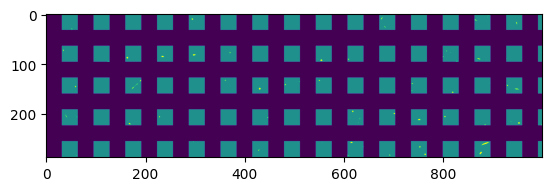

In [11]:
plt.imshow(prob_map[140, :, 12000:13000])